In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow Version: 2.20.0
Num GPUs Available: 1


In [2]:
plt.style.use("dark_background")
sns.set_theme(style="darkgrid")

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", x_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


In [4]:
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())
print("Mean Pixel Value:", x_train.mean())
print("Standard Deviation:", x_train.std())
print("Number of Classes:", len(np.unique(y_train)))

Minimum Pixel Value: 0
Maximum Pixel Value: 255
Mean Pixel Value: 33.318421449829934
Standard Deviation: 78.56748998339798
Number of Classes: 10


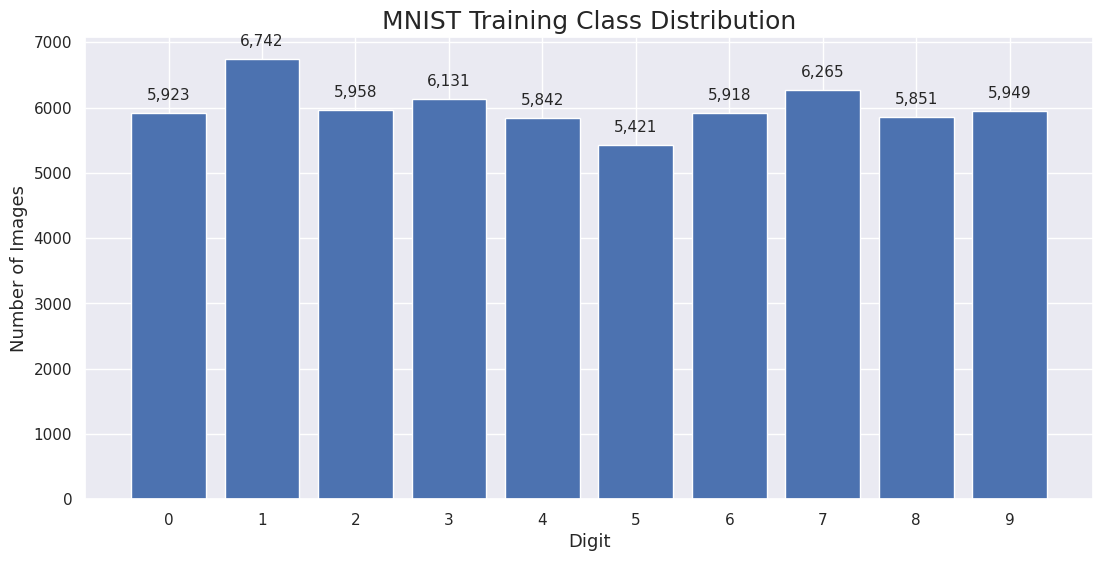

In [5]:
class_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure(figsize=(13, 6))
bars = plt.bar(class_counts.index, class_counts.values)

for bar, value in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 200,
        f"{value:,}",
        ha="center",
        fontsize=11
    )

plt.title("MNIST Training Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.xticks(range(10))
plt.show()

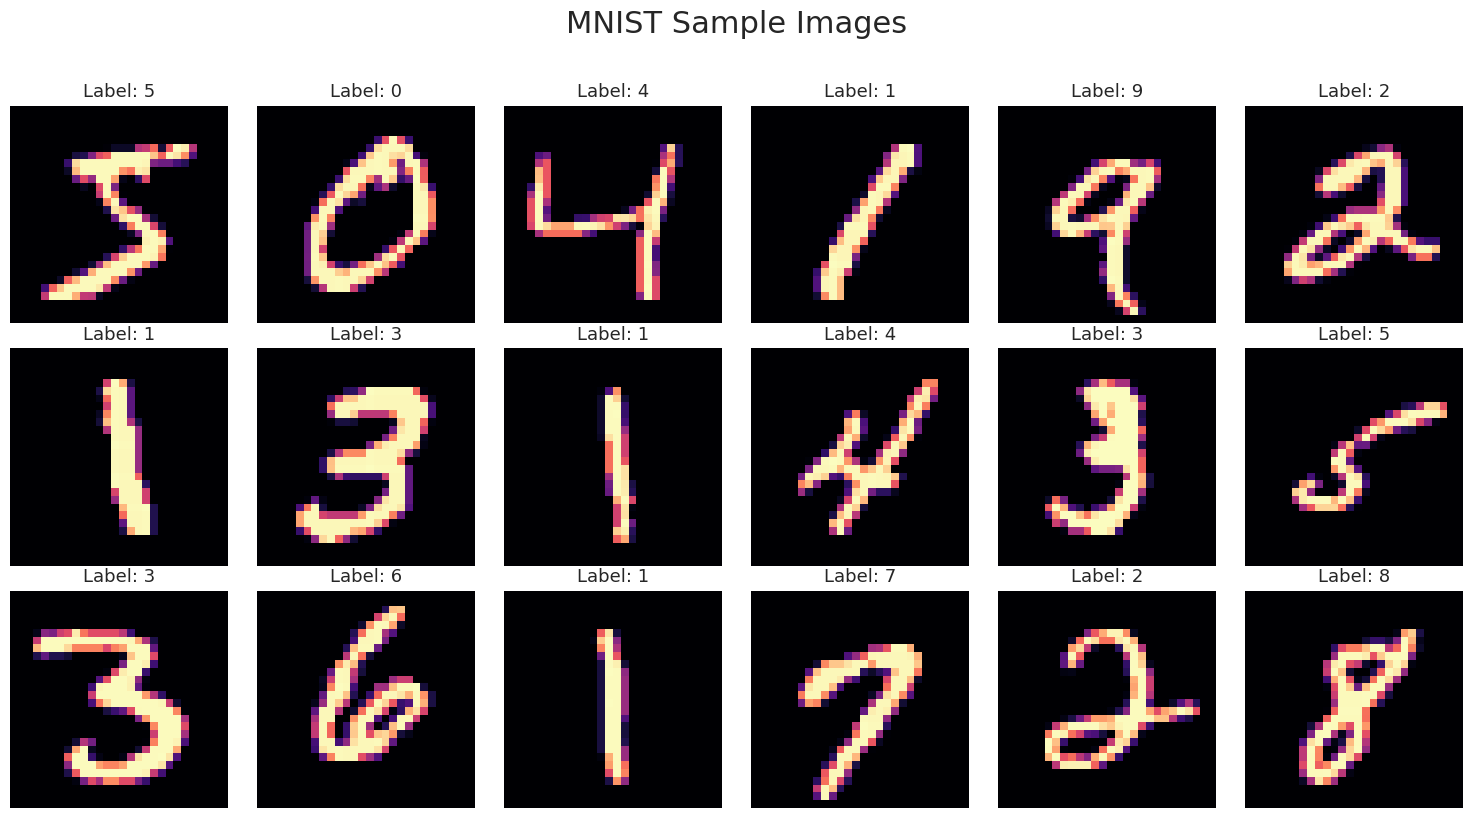

In [6]:
fig, axes = plt.subplots(3, 6, figsize=(15, 8))

for ax, image, label in zip(axes.ravel(), x_train[:18], y_train[:18]):
    ax.imshow(image, cmap="magma")
    ax.set_title(f"Label: {label}", fontsize=13)
    ax.axis("off")

plt.suptitle("MNIST Sample Images", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

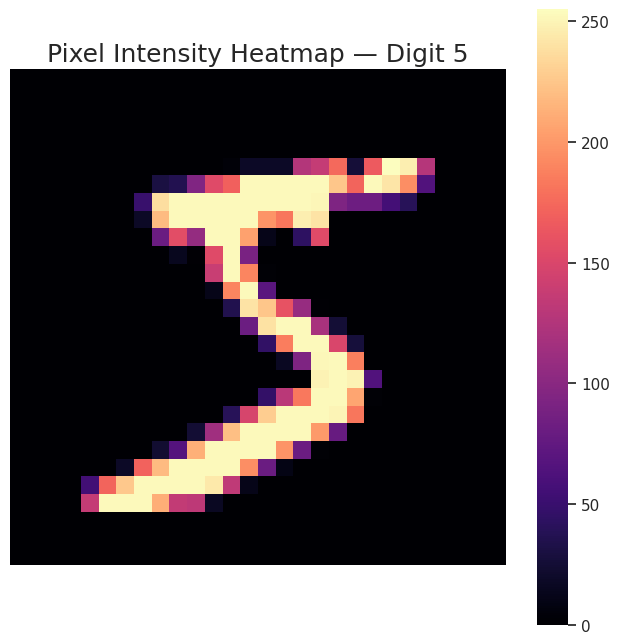

In [7]:
plt.figure(figsize=(8, 8))
sns.heatmap(
    x_train[0],
    cmap="magma",
    square=True,
    xticklabels=False,
    yticklabels=False
)
plt.title(f"Pixel Intensity Heatmap — Digit {y_train[0]}")
plt.show()

In [8]:
x_train = np.pad(x_train, ((0, 0), (2, 2), (2, 2)), mode="constant")
x_test = np.pad(x_test, ((0, 0), (2, 2), (2, 2)), mode="constant")

print("Training Shape After Padding:", x_train.shape)
print("Testing Shape After Padding:", x_test.shape)

Training Shape After Padding: (60000, 32, 32)
Testing Shape After Padding: (10000, 32, 32)


In [9]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print(x_train.shape)
print(x_test.shape)

(60000, 32, 32, 1)
(10000, 32, 32, 1)


In [10]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(y_train_cat.shape)
print(y_test_cat.shape)

(60000, 10)
(10000, 10)


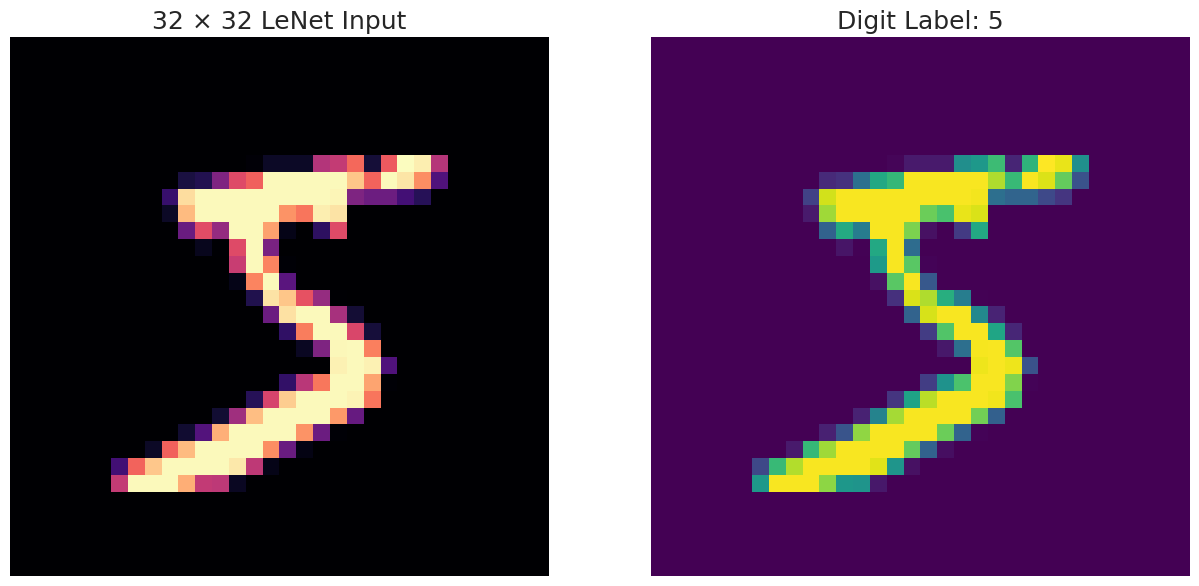

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].imshow(x_train[0].squeeze(), cmap="magma")
axes[0].set_title("32 × 32 LeNet Input")
axes[0].axis("off")

axes[1].imshow(x_train[0].squeeze(), cmap="viridis")
axes[1].set_title(f"Digit Label: {y_train[0]}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [12]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 1)),
    layers.Conv2D(6, (5, 5), activation="tanh", padding="valid", name="C1"),
    layers.AveragePooling2D(pool_size=(2, 2), strides=2, name="S2"),
    layers.Conv2D(16, (5, 5), activation="tanh", padding="valid", name="C3"),
    layers.AveragePooling2D(pool_size=(2, 2), strides=2, name="S4"),
    layers.Flatten(name="Flatten"),
    layers.Dense(120, activation="tanh", name="C5"),
    layers.Dense(84, activation="tanh", name="F6"),
    layers.Dense(10, activation="softmax", name="Output")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1 (Conv2D)                     │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2 (AveragePooling2D)           │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3 (Conv2D)                     │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4 (AveragePooling2D)           │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C5 (Dense)                      │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6 (Dense)                      │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
for layer in model.layers:
    print(f"{layer.name:12} -> {layer.output.shape}")

C1           -> (None, 28, 28, 6)
S2           -> (None, 14, 14, 6)
C3           -> (None, 10, 10, 16)
S4           -> (None, 5, 5, 16)
Flatten      -> (None, 400)
C5           -> (None, 120)
F6           -> (None, 84)
Output       -> (None, 10)


In [14]:
parameter_data = []

for layer in model.layers:
    parameter_data.append({
        "Layer": layer.name,
        "Parameters": layer.count_params()
    })

parameter_df = pd.DataFrame(parameter_data)
parameter_df["Percentage"] = (
    parameter_df["Parameters"] /
    parameter_df["Parameters"].sum() * 100
)

display(parameter_df)

print("Total Parameters:", model.count_params())

,Layer,Parameters,Percentage
0,C1,156,0.252812
1,S2,0,0.000000
2,C3,2416,3.915340
3,S4,0,0.000000
4,Flatten,0,0.000000
5,C5,48120,77.982692
6,F6,10164,16.471656
7,Output,850,1.377500


Total Parameters: 61706


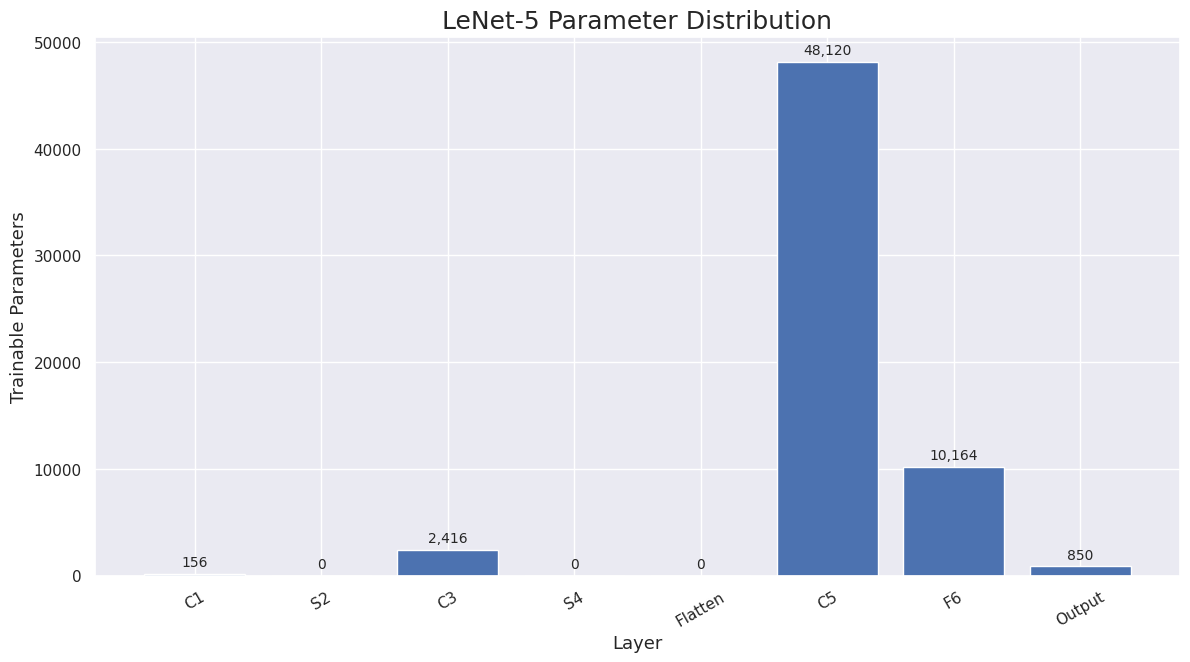

In [15]:
plt.figure(figsize=(14, 7))

bars = plt.bar(
    parameter_df["Layer"],
    parameter_df["Parameters"]
)

for bar, value in zip(bars, parameter_df["Parameters"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + parameter_df["Parameters"].max() * 0.015,
        f"{value:,}",
        ha="center",
        fontsize=10
    )

plt.title("LeNet-5 Parameter Distribution")
plt.xlabel("Layer")
plt.ylabel("Trainable Parameters")
plt.xticks(rotation=30)
plt.show()

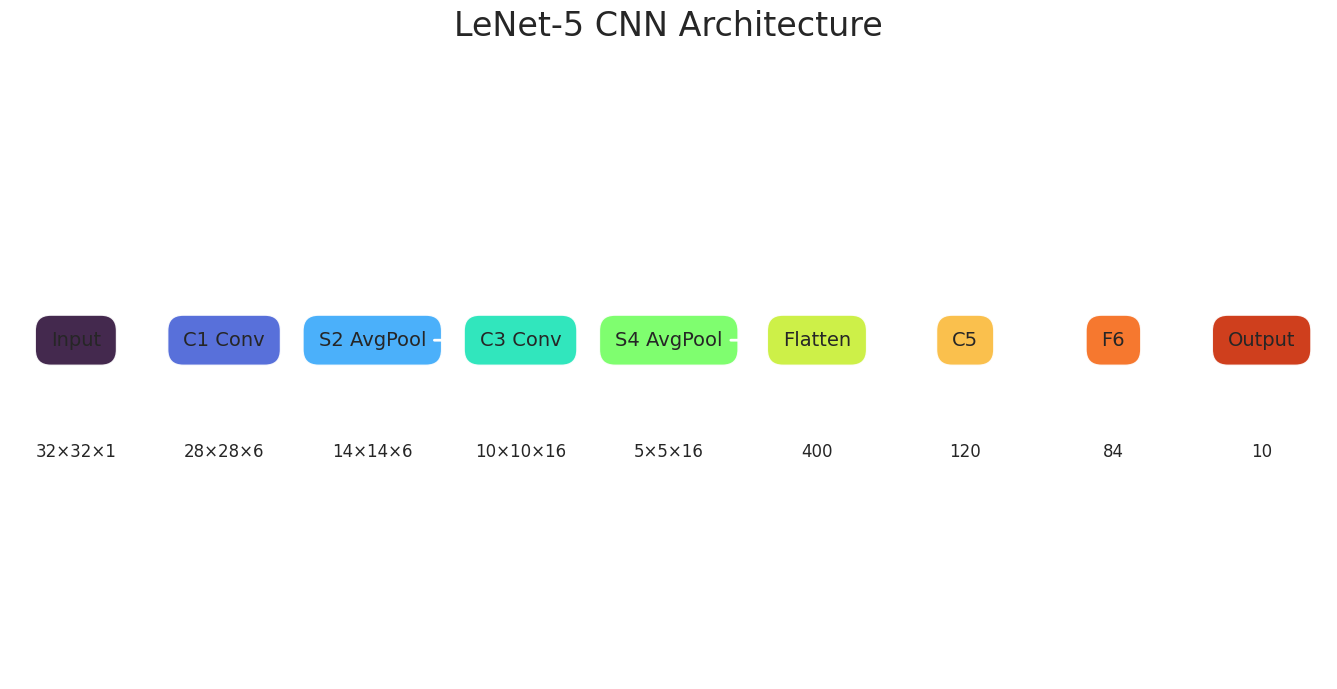

In [16]:
fig, ax = plt.subplots(figsize=(17, 8))

layers_info = [
    ("Input", "32×32×1"),
    ("C1 Conv", "28×28×6"),
    ("S2 AvgPool", "14×14×6"),
    ("C3 Conv", "10×10×16"),
    ("S4 AvgPool", "5×5×16"),
    ("Flatten", "400"),
    ("C5", "120"),
    ("F6", "84"),
    ("Output", "10")
]

x_positions = np.linspace(0.05, 0.95, len(layers_info))

for i, ((name, shape), x) in enumerate(zip(layers_info, x_positions)):
    ax.text(
        x,
        0.55,
        name,
        ha="center",
        va="center",
        fontsize=14,
        bbox=dict(
            boxstyle="round,pad=0.8",
            facecolor=plt.cm.turbo(i / len(layers_info)),
            alpha=0.9
        )
    )

    ax.text(
        x,
        0.37,
        shape,
        ha="center",
        va="center",
        fontsize=12
    )

    if i < len(layers_info) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i + 1] - 0.045, 0.55),
            xytext=(x + 0.045, 0.55),
            arrowprops=dict(
                arrowstyle="->",
                lw=2
            )
        )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("LeNet-5 CNN Architecture", fontsize=24, pad=20)

plt.show()

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.optimizer

In [18]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

In [19]:
history = model.fit(
    x_train,
    y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8955 - loss: 0.3603 - val_accuracy: 0.9613 - val_loss: 0.1316 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9600 - loss: 0.1323 - val_accuracy: 0.9757 - val_loss: 0.0856 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9735 - loss: 0.0870 - val_accuracy: 0.9807 - val_loss: 0.0681 - learning_rate: 0.0010
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9807 - loss: 0.0640 - val_accuracy: 0.9828 - val_loss: 0.0613 - learning_rate: 0.0010
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9853 - loss: 0.0497 - val_accuracy: 0.9822 - val_loss: 0.0590 - learning_rate: 0.0010
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9883 - loss: 0.0393 - val_accuracy: 0.9828 - val_loss: 0.0577 - learning_rate: 0.0010
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9906 - loss: 0.0312 

In [20]:
history_df = pd.DataFrame(history.history)

history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.895463,0.360326,0.961333,0.131556,0.0010
1,0.959963,0.132298,0.975667,0.085602,0.0010
2,0.973518,0.087016,0.980667,0.068108,0.0010
3,0.980722,0.064033,0.982833,0.061298,0.0010
4,0.985333,0.049679,0.982167,0.059029,0.0010
5,0.988259,0.039316,0.982833,0.057735,0.0010
6,0.990611,0.031229,0.983833,0.056589,0.0010
7,0.992796,0.025134,0.983333,0.055205,0.0010
8,0.994463,0.020399,0.986000,0.052953,0.0010
9,0.995833,0.016382,0.984500,0.058936,0.0010


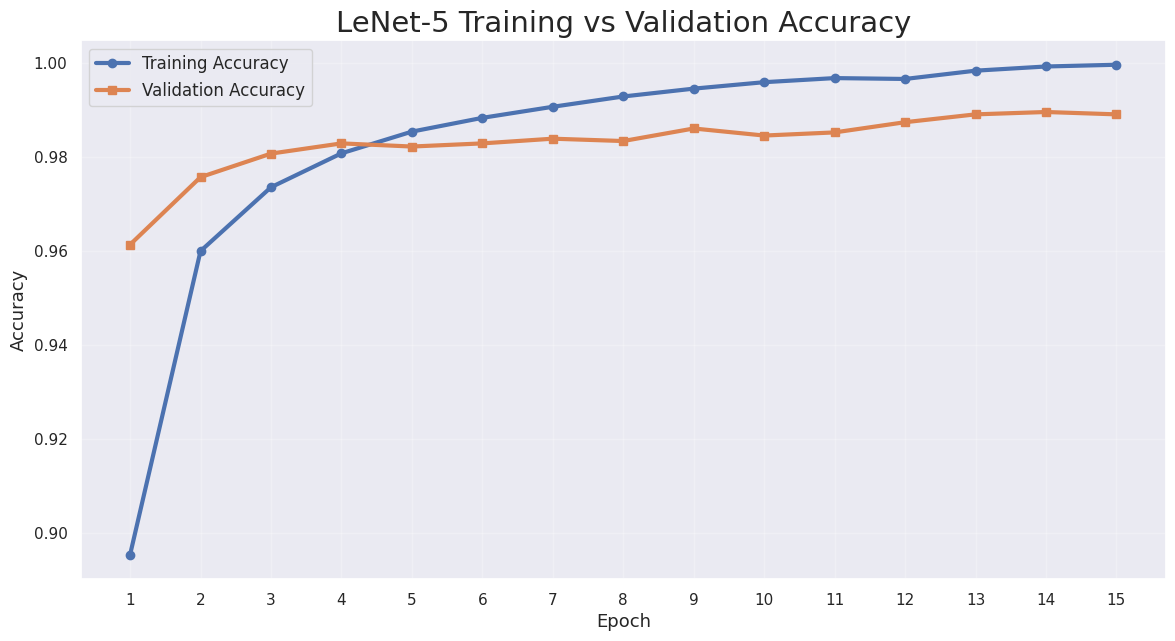

In [21]:
epochs_range = range(1, len(history_df) + 1)

plt.figure(figsize=(14, 7))

plt.plot(
    epochs_range,
    history_df["accuracy"],
    marker="o",
    linewidth=3,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history_df["val_accuracy"],
    marker="s",
    linewidth=3,
    label="Validation Accuracy"
)

plt.title("LeNet-5 Training vs Validation Accuracy", fontsize=21)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(alpha=0.25)

plt.show()

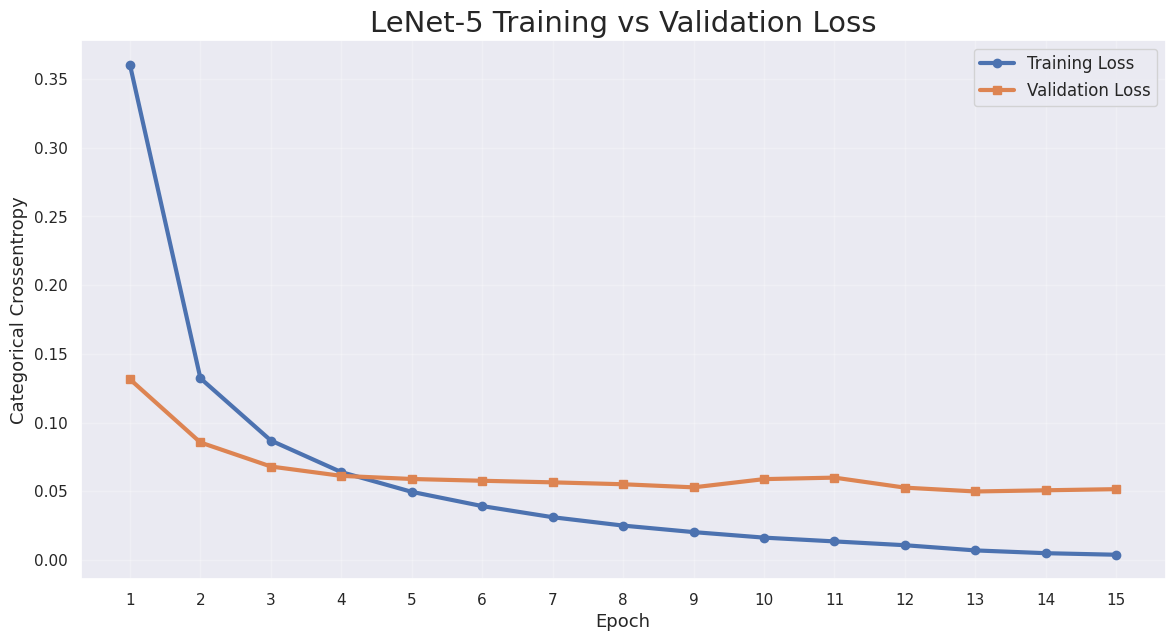

In [22]:
plt.figure(figsize=(14, 7))

plt.plot(
    epochs_range,
    history_df["loss"],
    marker="o",
    linewidth=3,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history_df["val_loss"],
    marker="s",
    linewidth=3,
    label="Validation Loss"
)

plt.title("LeNet-5 Training vs Validation Loss", fontsize=21)
plt.xlabel("Epoch")
plt.ylabel("Categorical Crossentropy")
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(alpha=0.25)

plt.show()

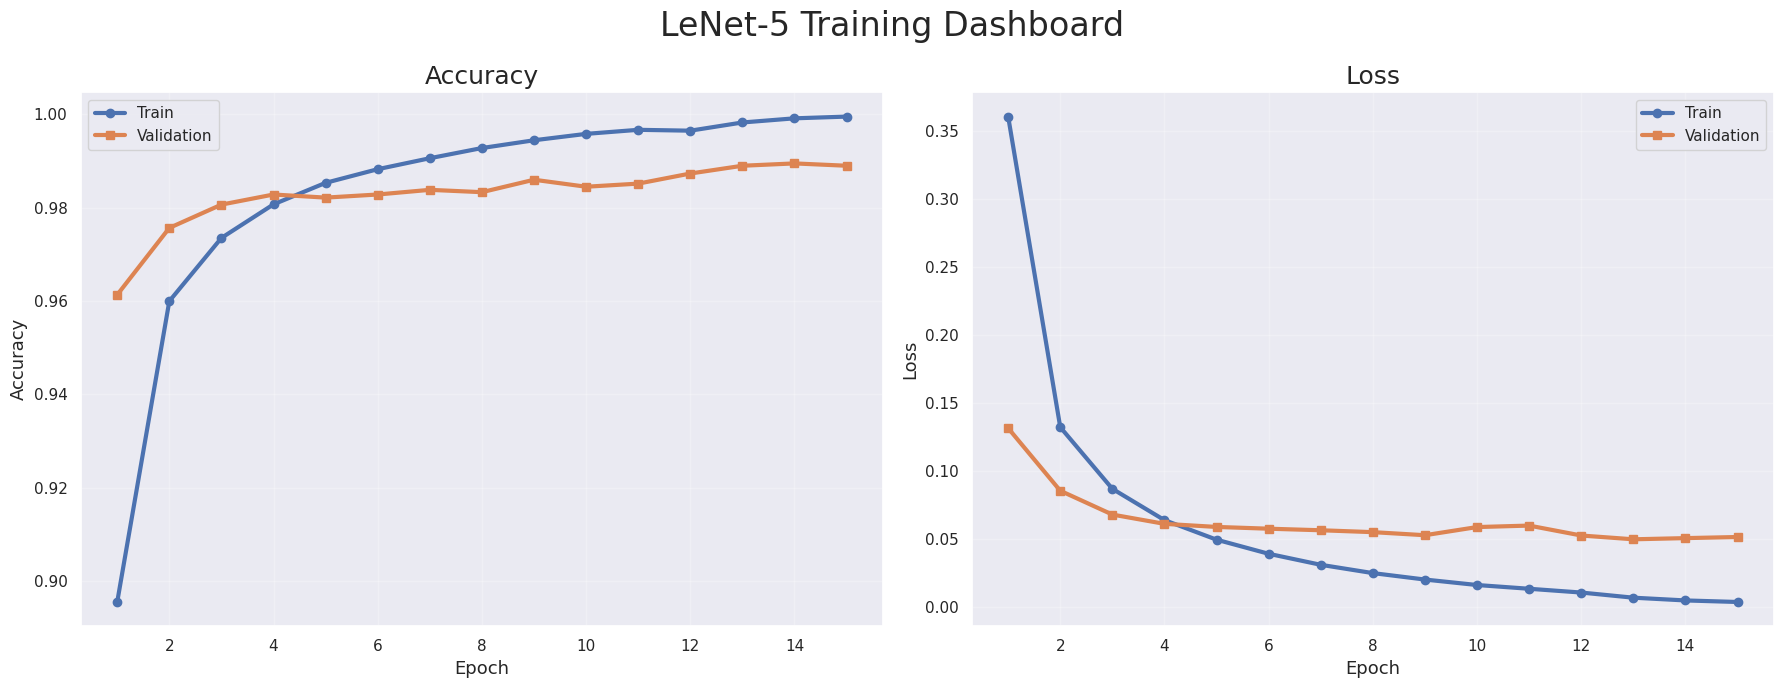

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].plot(
    epochs_range,
    history_df["accuracy"],
    marker="o",
    linewidth=3,
    label="Train"
)

axes[0].plot(
    epochs_range,
    history_df["val_accuracy"],
    marker="s",
    linewidth=3,
    label="Validation"
)

axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    epochs_range,
    history_df["loss"],
    marker="o",
    linewidth=3,
    label="Train"
)

axes[1].plot(
    epochs_range,
    history_df["val_loss"],
    marker="s",
    linewidth=3,
    label="Validation"
)

axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.suptitle("LeNet-5 Training Dashboard", fontsize=24)
plt.tight_layout()
plt.show()

In [24]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print(f"Test Loss: {test_loss:.5f}")
print(f"Test Accuracy: {test_accuracy:.5%}")

Test Loss: 0.04529
Test Accuracy: 98.72000%


In [25]:
probabilities = model.predict(
    x_test,
    batch_size=256,
    verbose=1
)

predictions = np.argmax(probabilities, axis=1)

print(predictions[:20])

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


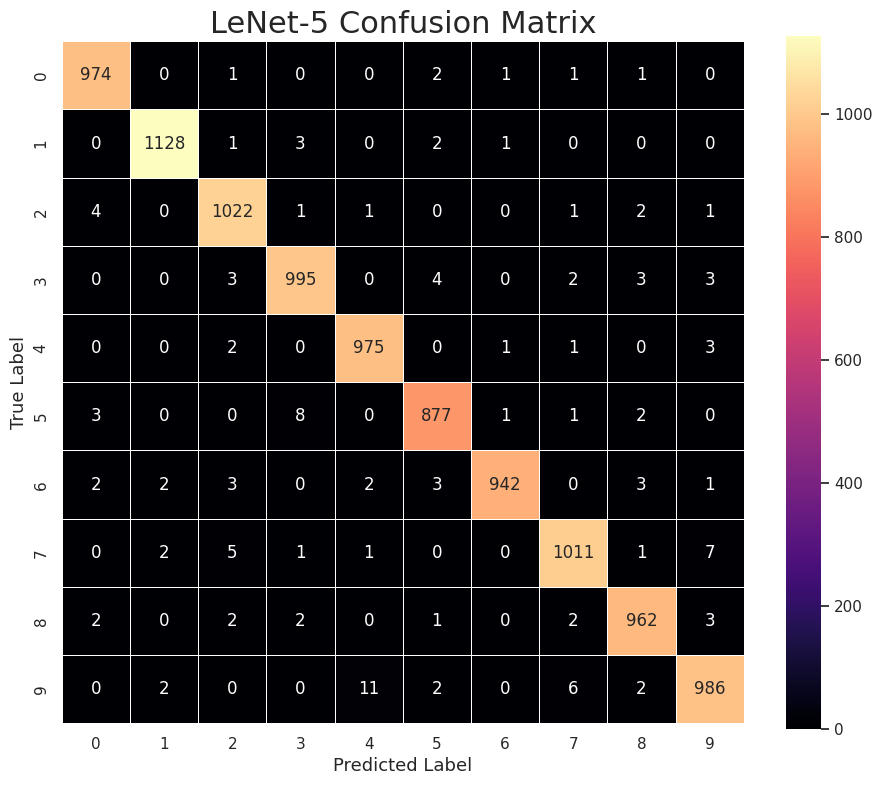

In [26]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="magma",
    square=True,
    linewidths=0.5
)

plt.title("LeNet-5 Confusion Matrix", fontsize=22)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

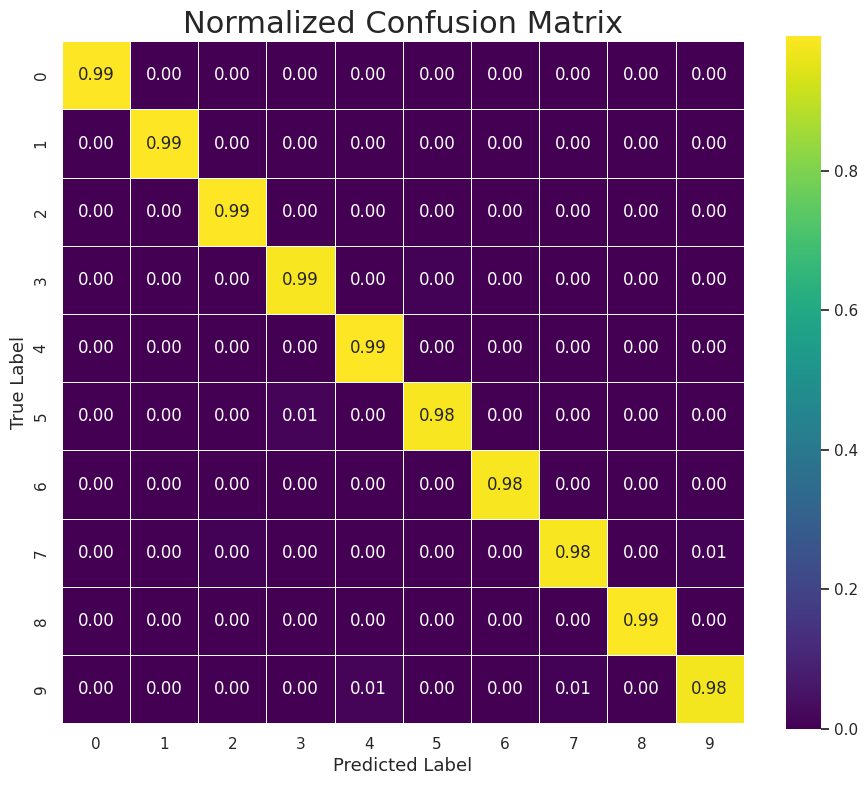

In [27]:
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    square=True,
    linewidths=0.5
)

plt.title("Normalized Confusion Matrix", fontsize=22)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [28]:
report = classification_report(
    y_test,
    predictions,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df.round(4))

,precision,recall,f1-score,support
0,0.9888,0.9939,0.9913,980.0000
1,0.9947,0.9938,0.9943,1135.0000
2,0.9836,0.9903,0.9870,1032.0000
3,0.9851,0.9851,0.9851,1010.0000
4,0.9848,0.9929,0.9888,982.0000
5,0.9843,0.9832,0.9837,892.0000
6,0.9958,0.9833,0.9895,958.0000
7,0.9863,0.9835,0.9849,1028.0000
8,0.9857,0.9877,0.9867,974.0000
9,0.9821,0.9772,0.9796,1009.0000


In [29]:
incorrect_indices = np.where(predictions != y_test)[0]
correct_indices = np.where(predictions == y_test)[0]

print("Correct Predictions:", len(correct_indices))
print("Incorrect Predictions:", len(incorrect_indices))

Correct Predictions: 9872
Incorrect Predictions: 128


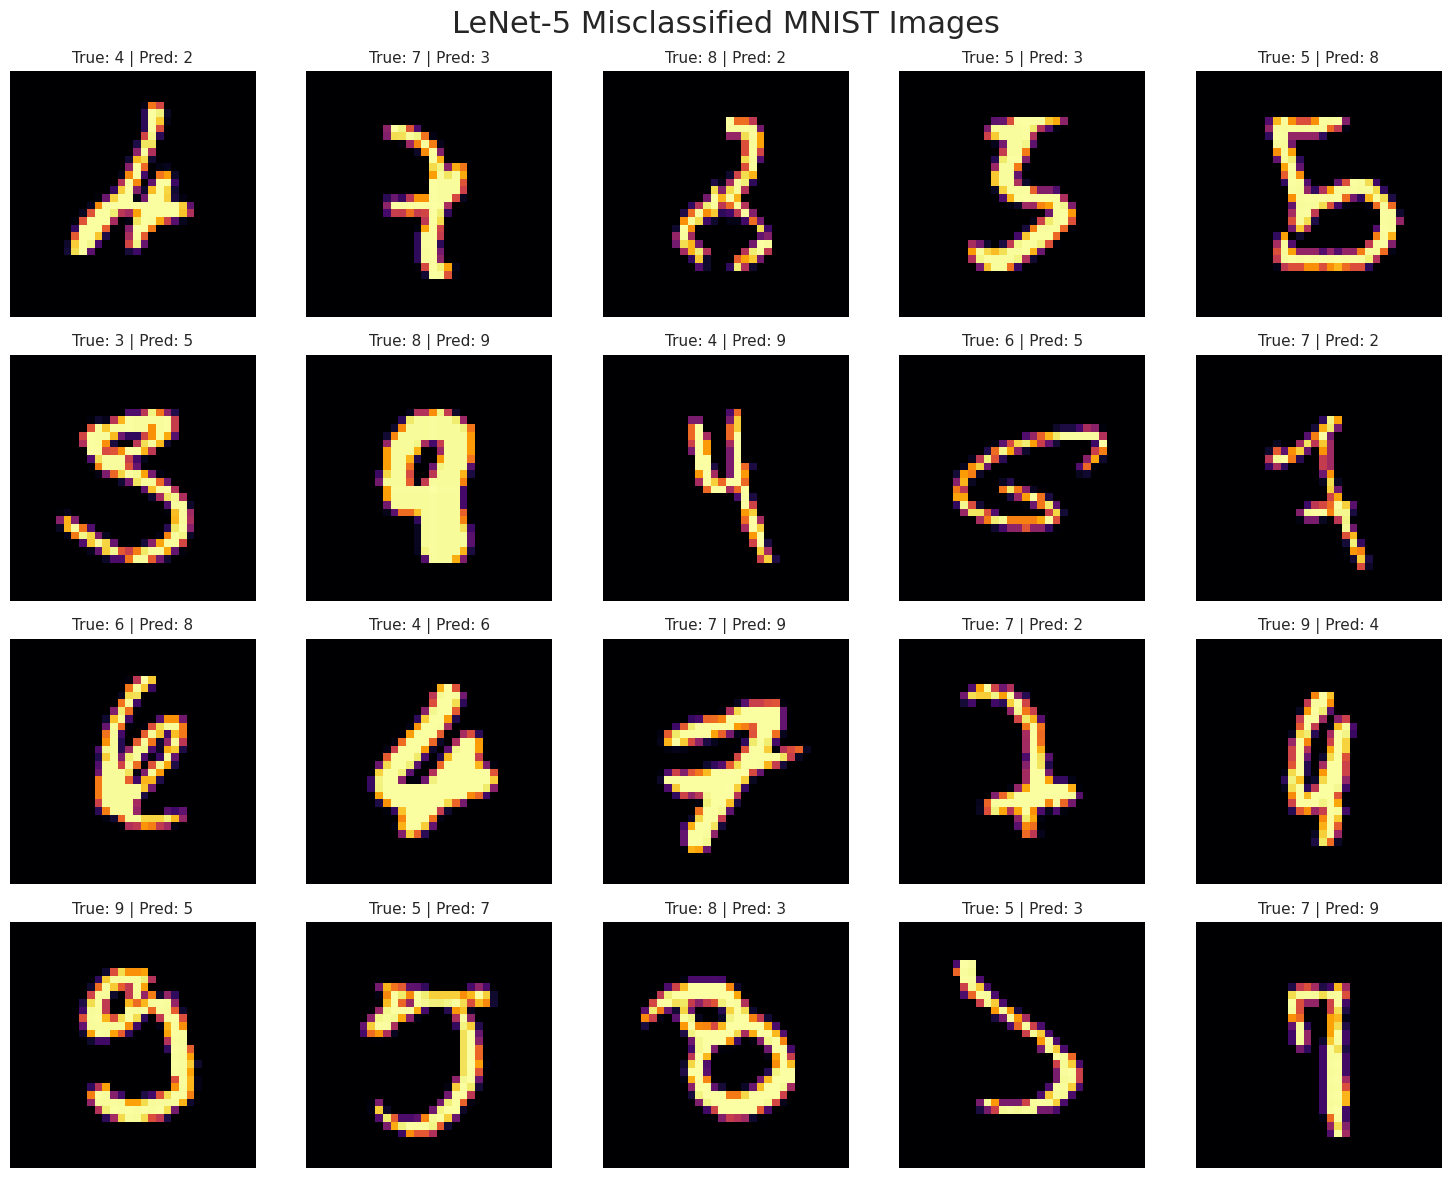

In [30]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for ax, idx in zip(axes.ravel(), incorrect_indices[:20]):
    ax.imshow(x_test[idx].squeeze(), cmap="inferno")
    ax.set_title(
        f"True: {y_test[idx]} | Pred: {predictions[idx]}",
        fontsize=11
    )
    ax.axis("off")

plt.suptitle("LeNet-5 Misclassified MNIST Images", fontsize=22)
plt.tight_layout()
plt.show()

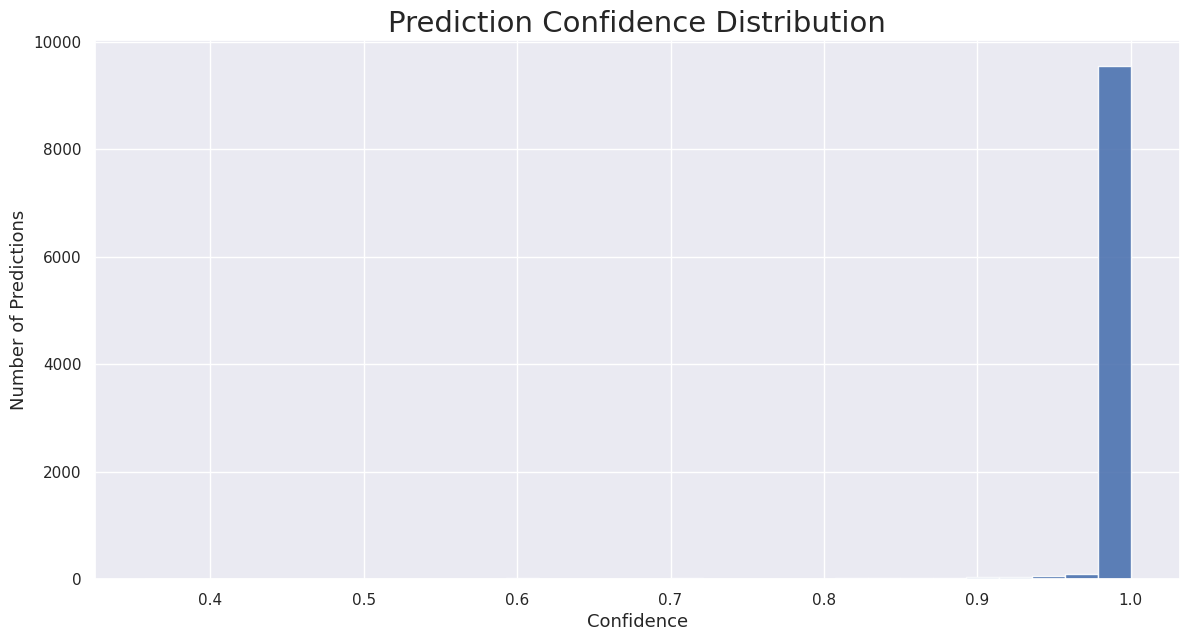

In [31]:
confidence = probabilities.max(axis=1)

plt.figure(figsize=(14, 7))

plt.hist(
    confidence,
    bins=30,
    edgecolor="white",
    alpha=0.9
)

plt.title("Prediction Confidence Distribution", fontsize=21)
plt.xlabel("Confidence")
plt.ylabel("Number of Predictions")

plt.show()

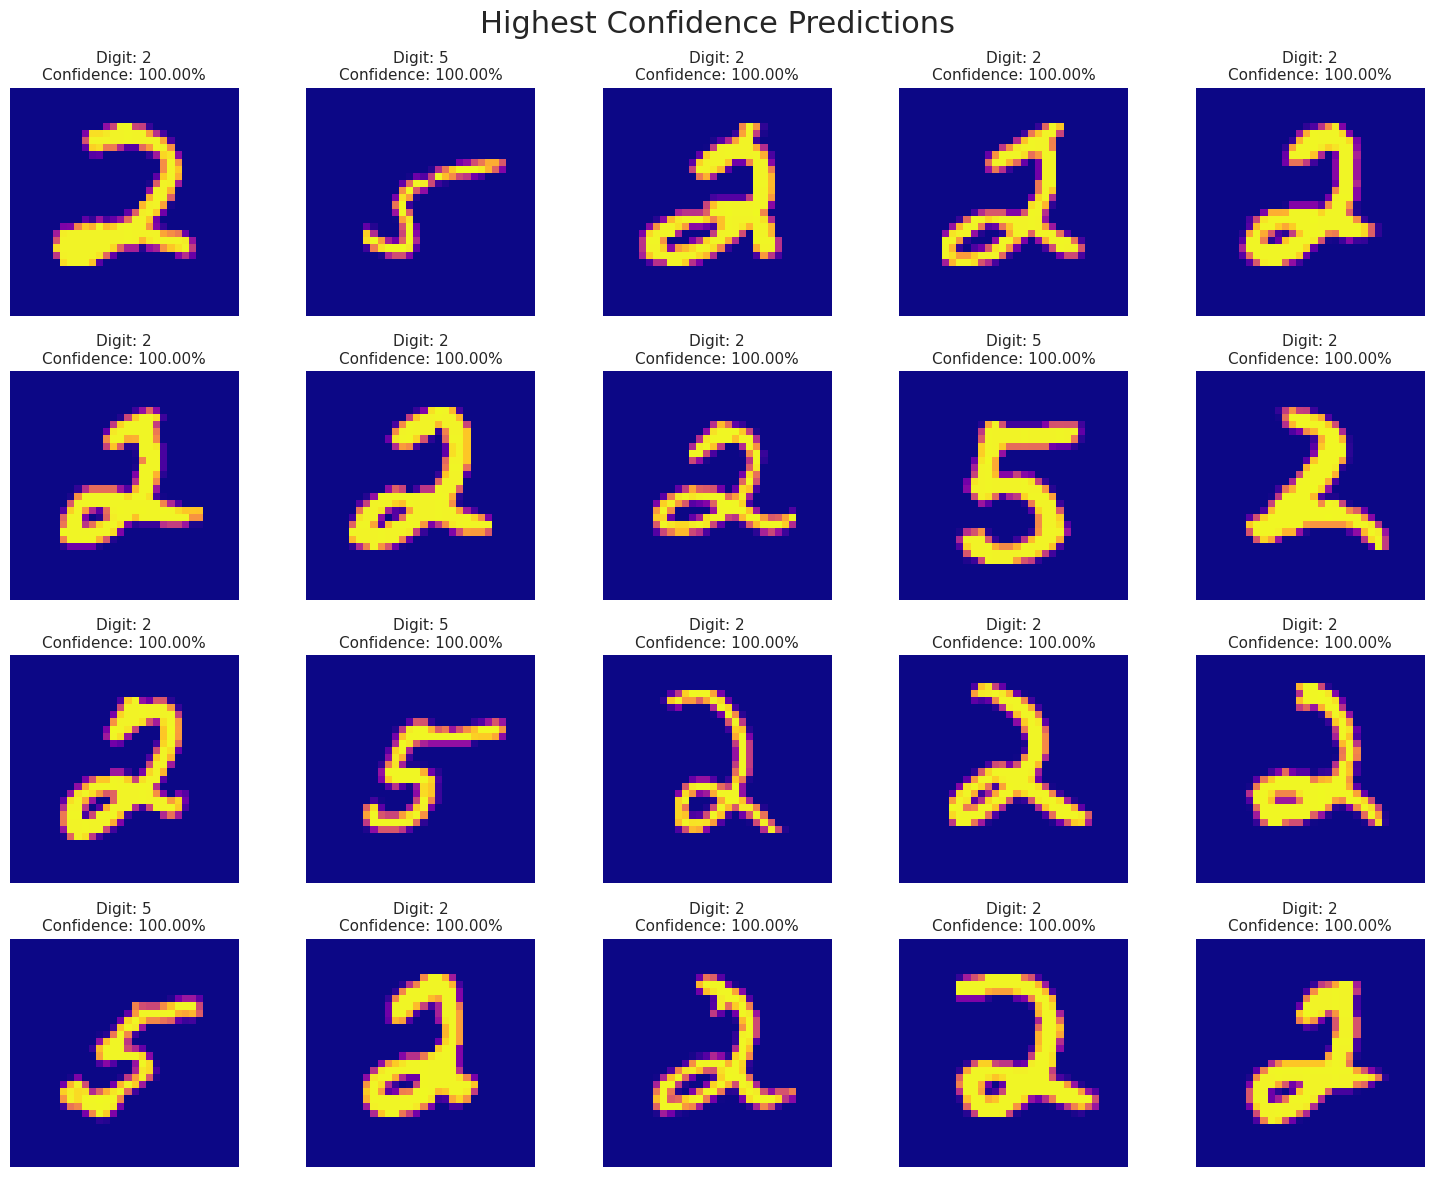

In [32]:
top_indices = np.argsort(confidence)[-20:][::-1]

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for ax, idx in zip(axes.ravel(), top_indices):
    ax.imshow(x_test[idx].squeeze(), cmap="plasma")
    ax.set_title(
        f"Digit: {predictions[idx]}\nConfidence: {confidence[idx]:.2%}",
        fontsize=11
    )
    ax.axis("off")

plt.suptitle("Highest Confidence Predictions", fontsize=22)
plt.tight_layout()
plt.show()

In [33]:
conv1_weights = model.get_layer("C1").get_weights()[0]

print("C1 Filter Shape:", conv1_weights.shape)

C1 Filter Shape: (5, 5, 1, 6)


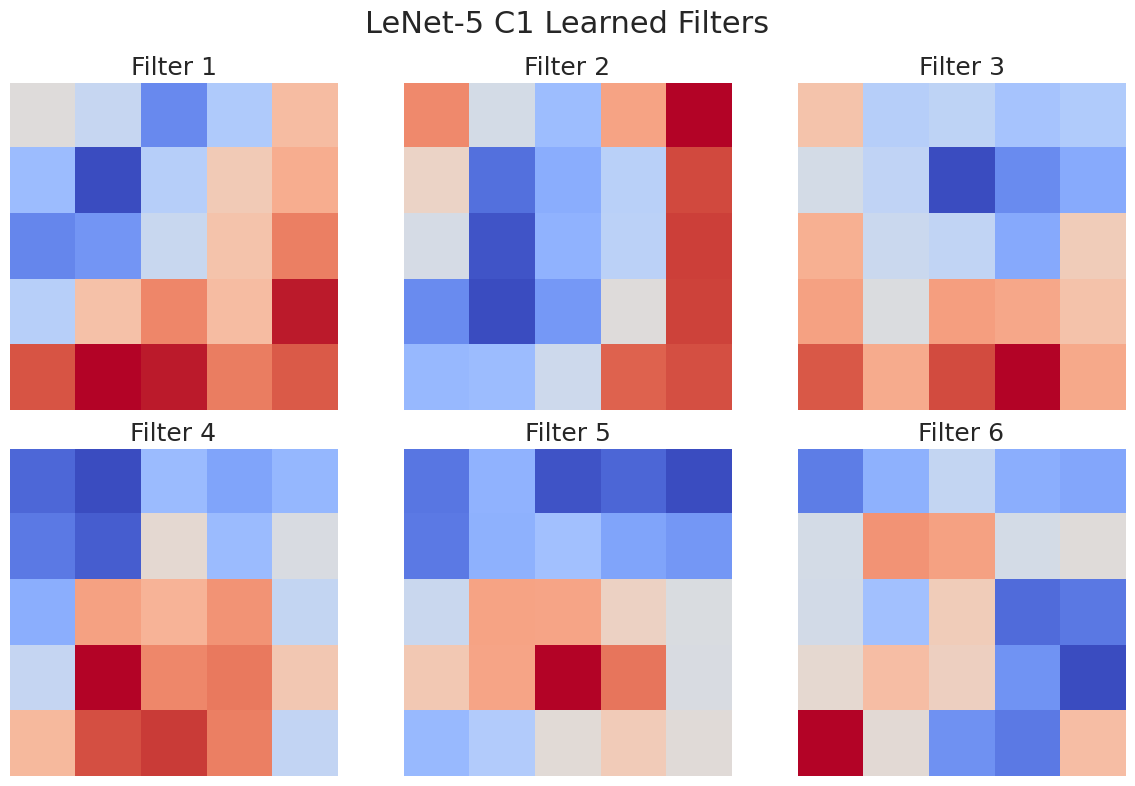

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, ax in enumerate(axes.ravel()):
    kernel = conv1_weights[:, :, 0, i]
    ax.imshow(kernel, cmap="coolwarm")
    ax.set_title(f"Filter {i + 1}")
    ax.axis("off")

plt.suptitle("LeNet-5 C1 Learned Filters", fontsize=22)
plt.tight_layout()
plt.show()

In [35]:
filter_means = conv1_weights.mean(axis=(0, 1, 2))
filter_stds = conv1_weights.std(axis=(0, 1, 2))

filter_df = pd.DataFrame({
    "Filter": np.arange(1, 7),
    "Mean": filter_means,
    "Std": filter_stds
})

display(filter_df)

,Filter,Mean,Std
0,1,-0.041516,0.241481
1,2,-0.092136,0.243265
2,3,-0.046488,0.247602
3,4,0.001402,0.252841
4,5,0.070114,0.239118
5,6,-0.045981,0.136271


In [36]:
conv2_weights = model.get_layer("C3").get_weights()[0]

print("C3 Filter Shape:", conv2_weights.shape)
print("Total C3 Parameters:", model.get_layer("C3").count_params())

C3 Filter Shape: (5, 5, 6, 16)
Total C3 Parameters: 2416


In [37]:
sample_image = x_test[0:1]

_ = model(sample_image)

activation_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer("C1").output,
        model.get_layer("S2").output,
        model.get_layer("C3").output,
        model.get_layer("S4").output
    ]
)

In [38]:
sample_image = x_test[0:1]

activations = activation_model.predict(
    sample_image,
    verbose=0
)

for i, activation in enumerate(activations):
    print(f"Activation {i + 1} Shape:", activation.shape)

Activation 1 Shape: (1, 28, 28, 6)
Activation 2 Shape: (1, 14, 14, 6)
Activation 3 Shape: (1, 10, 10, 16)
Activation 4 Shape: (1, 5, 5, 16)


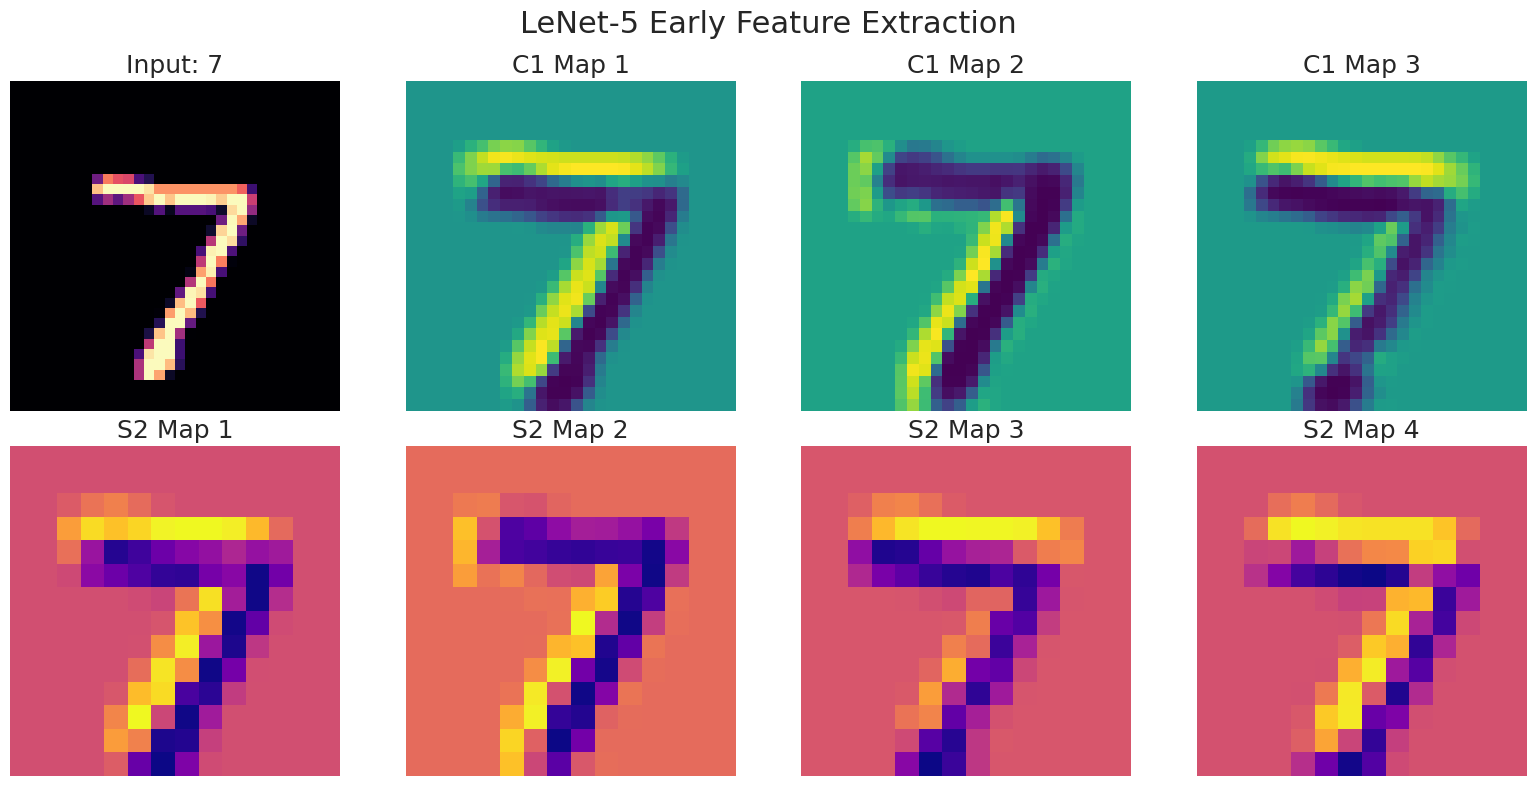

In [39]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0, 0].imshow(sample_image[0].squeeze(), cmap="magma")
axes[0, 0].set_title(f"Input: {y_test[0]}")
axes[0, 0].axis("off")

for i in range(3):
    axes[0, i + 1].imshow(
        activations[0][0, :, :, i],
        cmap="viridis"
    )
    axes[0, i + 1].set_title(f"C1 Map {i + 1}")
    axes[0, i + 1].axis("off")

for i in range(4):
    axes[1, i].imshow(
        activations[1][0, :, :, i],
        cmap="plasma"
    )
    axes[1, i].set_title(f"S2 Map {i + 1}")
    axes[1, i].axis("off")

plt.suptitle("LeNet-5 Early Feature Extraction", fontsize=22)
plt.tight_layout()
plt.show()

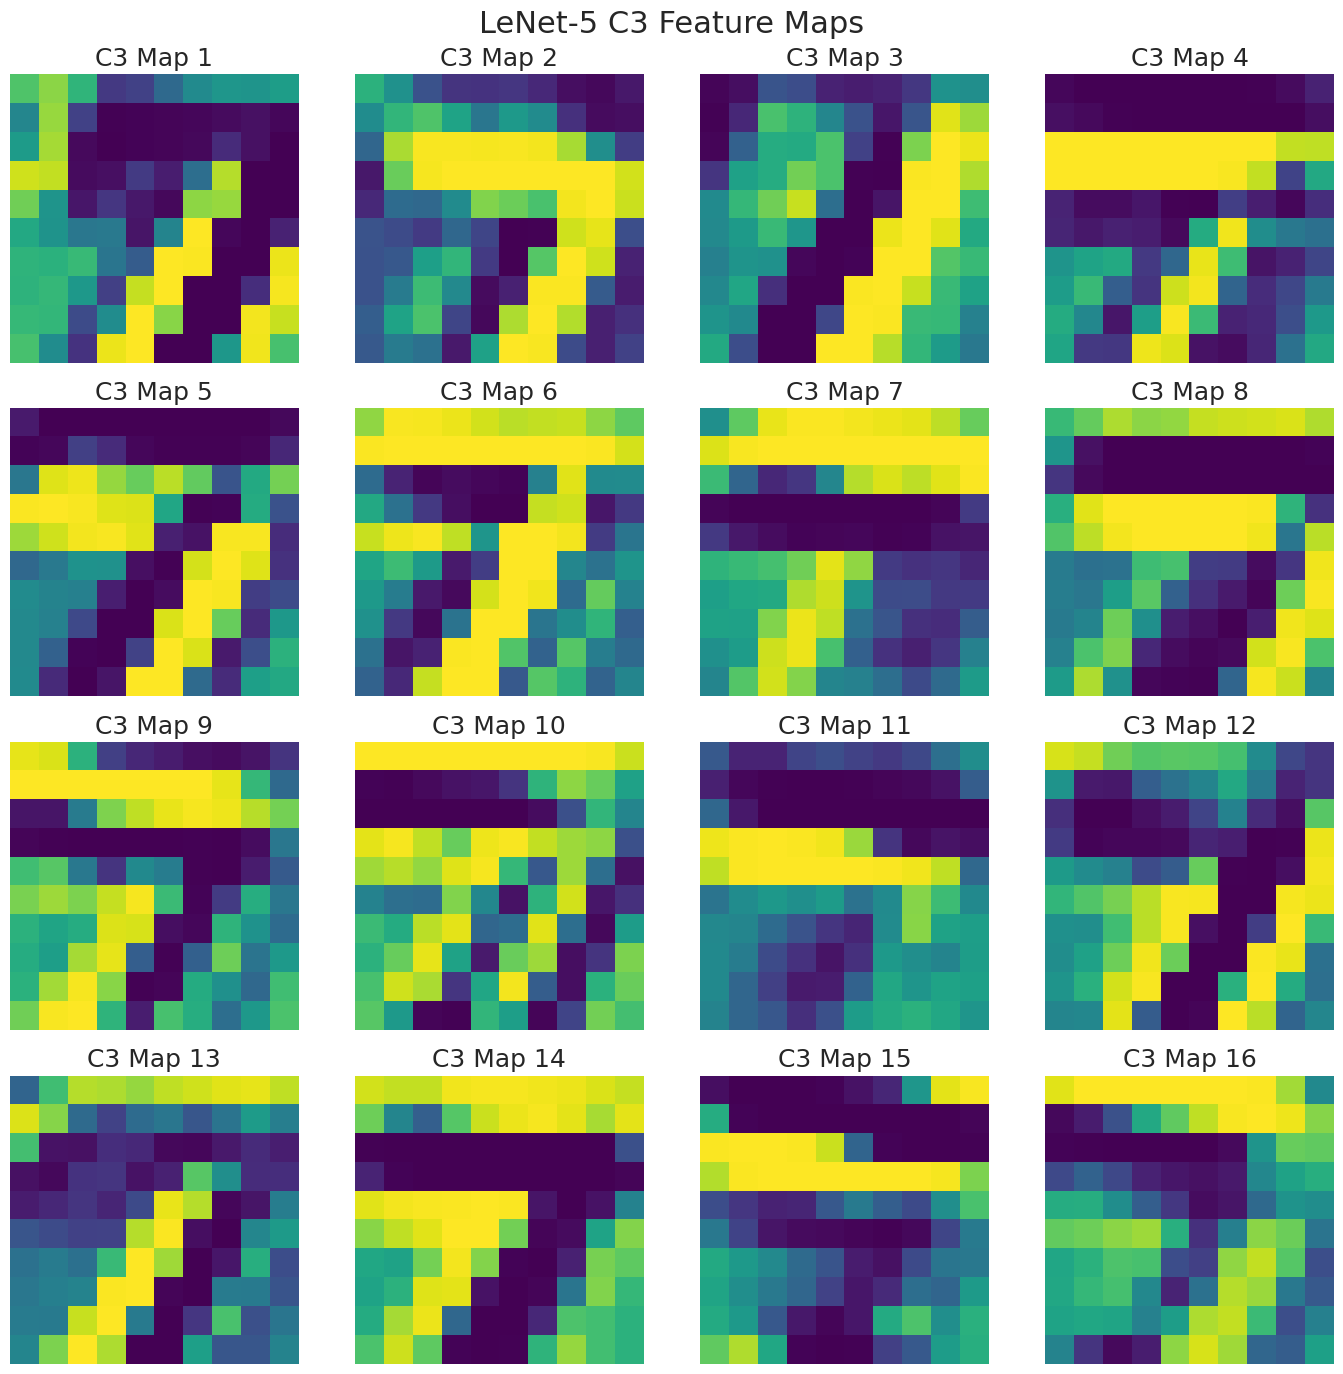

In [40]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(
        activations[2][0, :, :, i],
        cmap="viridis"
    )
    ax.set_title(f"C3 Map {i + 1}")
    ax.axis("off")

plt.suptitle("LeNet-5 C3 Feature Maps", fontsize=22)
plt.tight_layout()
plt.show()

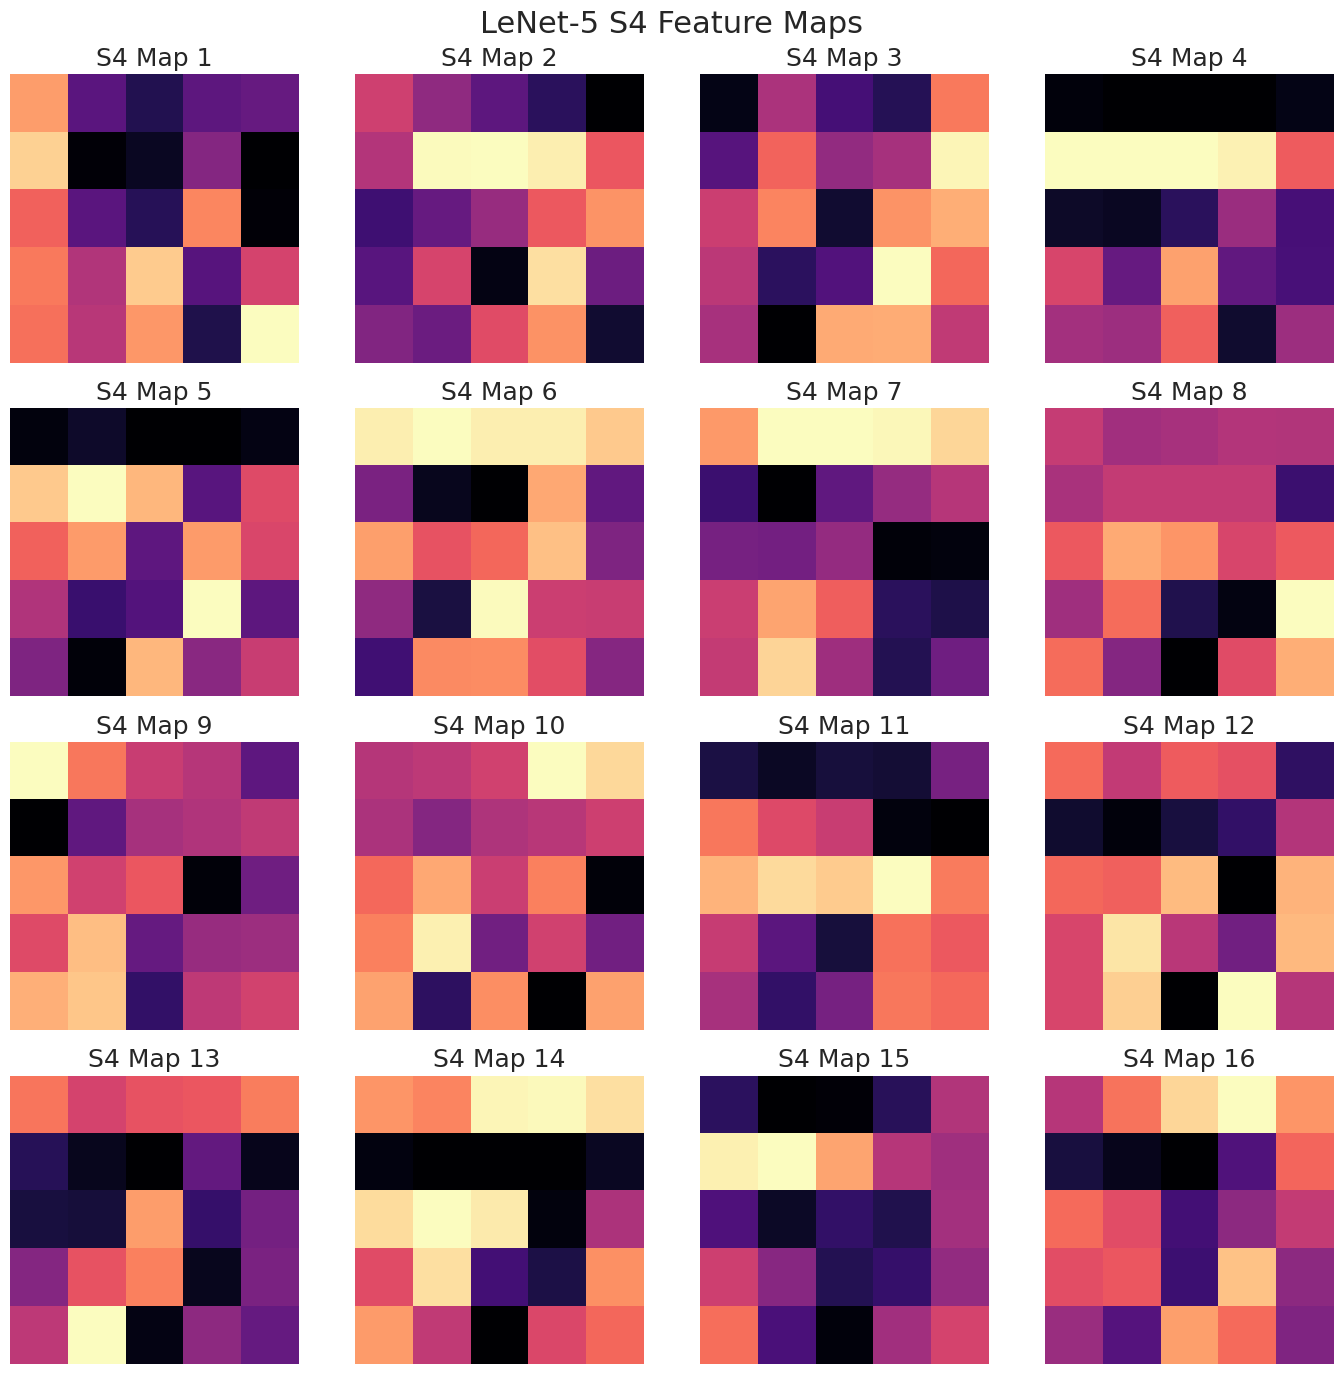

In [41]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(
        activations[3][0, :, :, i],
        cmap="magma"
    )
    ax.set_title(f"S4 Map {i + 1}")
    ax.axis("off")

plt.suptitle("LeNet-5 S4 Feature Maps", fontsize=22)
plt.tight_layout()
plt.show()

In [42]:
sample = x_test[12:13]

layer_outputs = [
    layer.output
    for layer in model.layers
    if layer.name not in ["Flatten"]
]

visual_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=layer_outputs
)

outputs = visual_model.predict(
    sample,
    verbose=0
)

for layer, output in zip(
    [layer for layer in model.layers if layer.name != "Flatten"],
    outputs
):
    print(
        f"{layer.name:10} | Shape: {str(output.shape):20} | Min: {output.min():.4f} | Max: {output.max():.4f}"
    )

C1         | Shape: (1, 28, 28, 6)       | Min: -0.9971 | Max: 0.9930
S2         | Shape: (1, 14, 14, 6)       | Min: -0.9937 | Max: 0.9766
C3         | Shape: (1, 10, 10, 16)      | Min: -1.0000 | Max: 1.0000
S4         | Shape: (1, 5, 5, 16)        | Min: -0.9999 | Max: 0.9986
C5         | Shape: (1, 120)             | Min: -1.0000 | Max: 1.0000
F6         | Shape: (1, 84)              | Min: -0.9995 | Max: 0.9982
Output     | Shape: (1, 10)              | Min: 0.0000 | Max: 0.9997


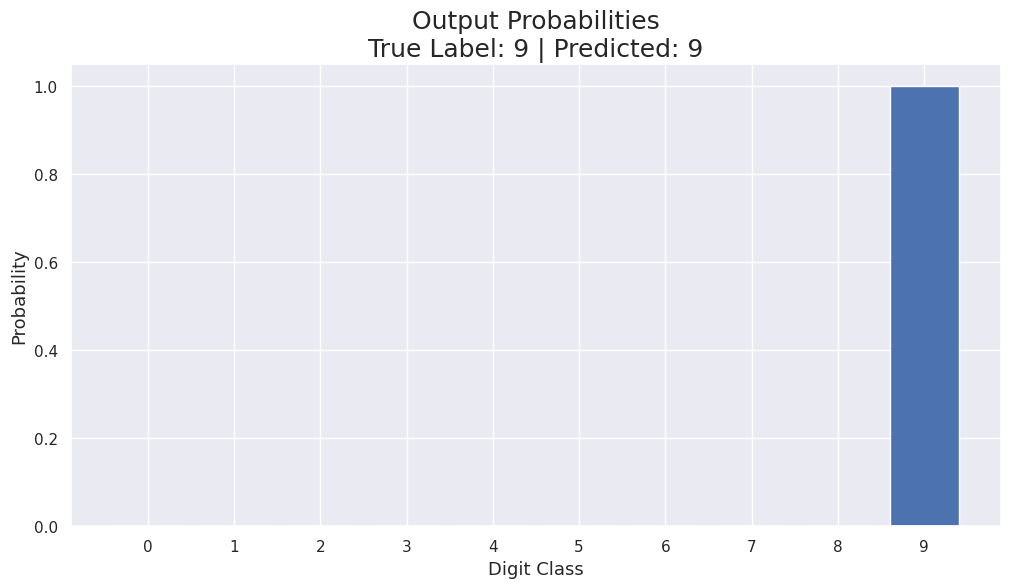

In [43]:
sample_index = 12

plt.figure(figsize=(12, 6))

bars = plt.bar(
    range(10),
    probabilities[sample_index]
)

plt.xticks(range(10))
plt.xlabel("Digit Class")
plt.ylabel("Probability")
plt.title(
    f"Output Probabilities\nTrue Label: {y_test[sample_index]} | Predicted: {predictions[sample_index]}"
)

plt.show()

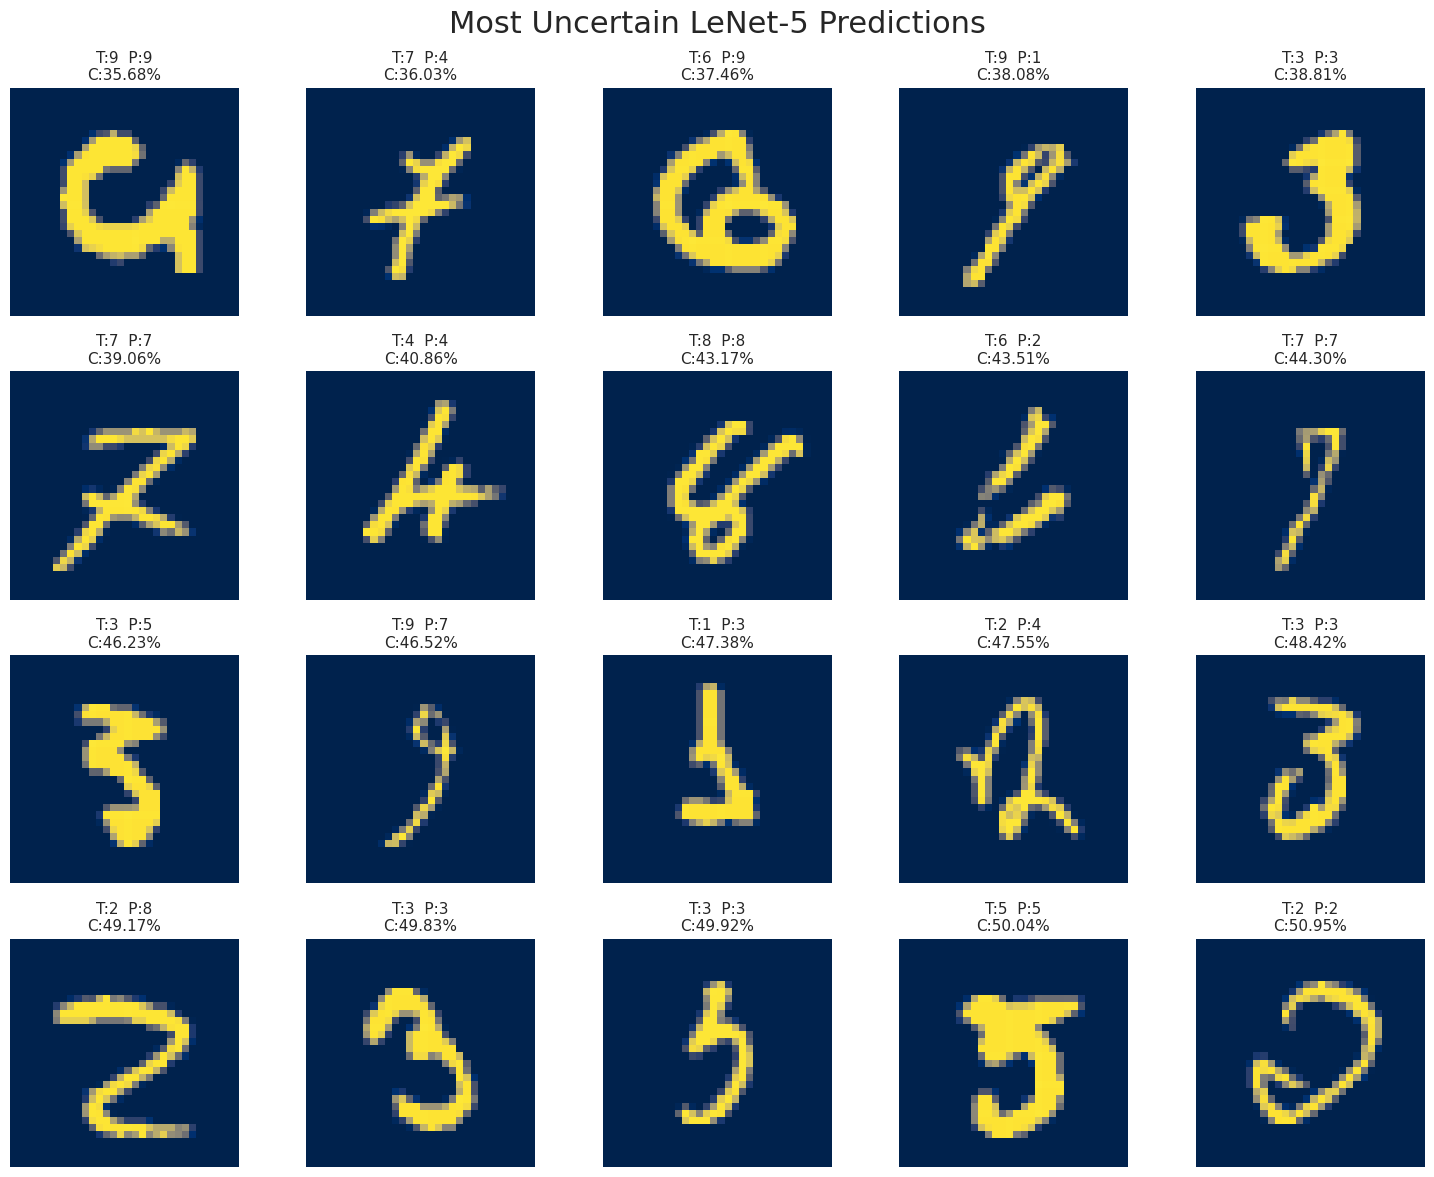

In [44]:
uncertain_indices = np.argsort(confidence)[:20]

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for ax, idx in zip(axes.ravel(), uncertain_indices):
    ax.imshow(x_test[idx].squeeze(), cmap="cividis")
    ax.set_title(
        f"T:{y_test[idx]}  P:{predictions[idx]}\nC:{confidence[idx]:.2%}",
        fontsize=11
    )
    ax.axis("off")

plt.suptitle("Most Uncertain LeNet-5 Predictions", fontsize=22)
plt.tight_layout()
plt.show()

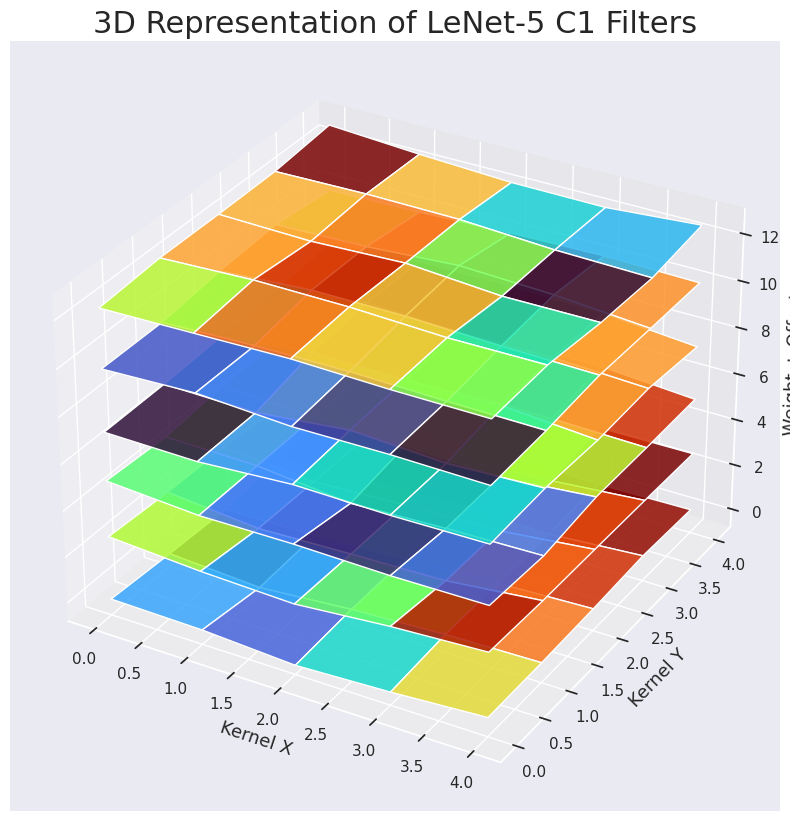

In [45]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection="3d")

x_grid, y_grid = np.meshgrid(
    np.arange(5),
    np.arange(5)
)

for i in range(6):
    z = conv1_weights[:, :, 0, i]
    offset = i * 2.5

    ax.plot_surface(
        x_grid,
        y_grid,
        z + offset,
        cmap="turbo",
        alpha=0.85
    )

ax.set_title("3D Representation of LeNet-5 C1 Filters", fontsize=22)
ax.set_xlabel("Kernel X")
ax.set_ylabel("Kernel Y")
ax.set_zlabel("Weight + Offset")

plt.show()

In [46]:
accuracy_history = history_df["accuracy"].values
val_accuracy_history = history_df["val_accuracy"].values
loss_history = history_df["loss"].values
val_loss_history = history_df["val_loss"].values

In [47]:
fig, ax = plt.subplots(figsize=(12, 7))

line1, = ax.plot([], [], linewidth=3, marker="o", label="Training Accuracy")
line2, = ax.plot([], [], linewidth=3, marker="s", label="Validation Accuracy")

ax.set_xlim(1, len(accuracy_history))
ax.set_ylim(
    min(accuracy_history.min(), val_accuracy_history.min()) - 0.02,
    max(accuracy_history.max(), val_accuracy_history.max()) + 0.02
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("LeNet-5 Accuracy Learning Process", fontsize=21)
ax.legend()

def update(frame):
    epoch = np.arange(1, frame + 2)
    line1.set_data(epoch, accuracy_history[:frame + 1])
    line2.set_data(epoch, val_accuracy_history[:frame + 1])
    ax.set_title(
        f"LeNet-5 Accuracy Learning Process — Epoch {frame + 1}",
        fontsize=21
    )
    return line1, line2

animation = FuncAnimation(
    fig,
    update,
    frames=len(accuracy_history),
    interval=700,
    repeat=False
)

plt.close(fig)
HTML(animation.to_jshtml())

In [48]:
fig, ax = plt.subplots(figsize=(12, 7))

line1, = ax.plot([], [], linewidth=3, marker="o", label="Training Loss")
line2, = ax.plot([], [], linewidth=3, marker="s", label="Validation Loss")

ax.set_xlim(1, len(loss_history))

ax.set_ylim(
    min(loss_history.min(), val_loss_history.min()) * 0.9,
    max(loss_history.max(), val_loss_history.max()) * 1.1
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("LeNet-5 Loss Learning Process", fontsize=21)
ax.legend()

def update(frame):
    epoch = np.arange(1, frame + 2)

    line1.set_data(
        epoch,
        loss_history[:frame + 1]
    )

    line2.set_data(
        epoch,
        val_loss_history[:frame + 1]
    )

    ax.set_title(
        f"LeNet-5 Loss Learning Process — Epoch {frame + 1}",
        fontsize=21
    )

    return line1, line2

animation = FuncAnimation(
    fig,
    update,
    frames=len(loss_history),
    interval=700,
    repeat=False
)

plt.close(fig)
HTML(animation.to_jshtml())

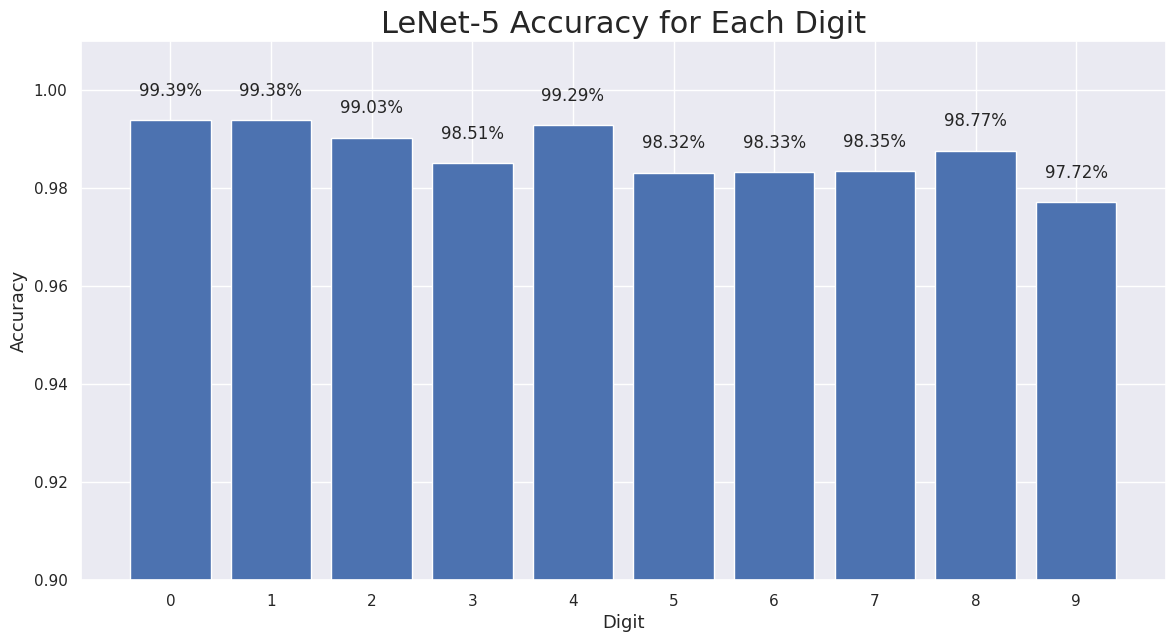

In [49]:
per_class_accuracy = []

for digit in range(10):
    mask = y_test == digit
    accuracy = np.mean(predictions[mask] == y_test[mask])
    per_class_accuracy.append(accuracy)

per_class_accuracy = np.array(per_class_accuracy)

plt.figure(figsize=(14, 7))

bars = plt.bar(
    range(10),
    per_class_accuracy
)

for bar, value in zip(bars, per_class_accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.005,
        f"{value:.2%}",
        ha="center"
    )

plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.01)
plt.title("LeNet-5 Accuracy for Each Digit", fontsize=22)

plt.show()

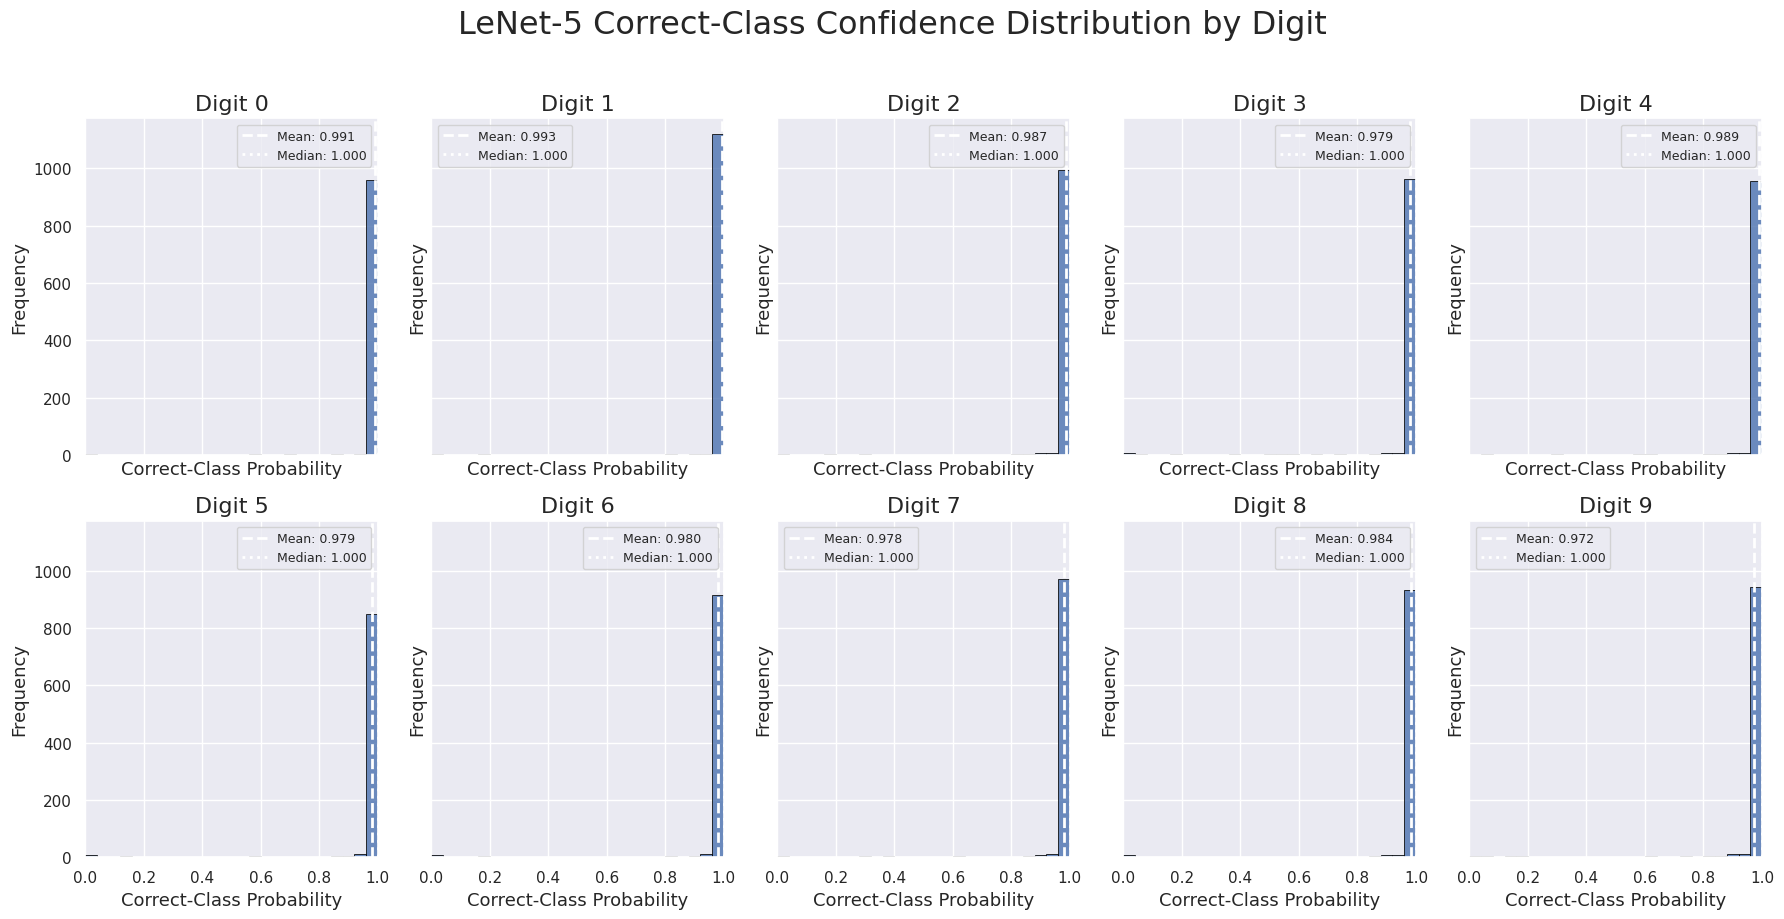

In [50]:
fig, axes = plt.subplots(2, 5, figsize=(18, 9), sharex=True, sharey=True)

for digit, ax in enumerate(axes.ravel()):
    values = probabilities[y_test == digit, digit]

    ax.hist(
        values,
        bins=np.linspace(0, 1, 26),
        alpha=0.8,
        edgecolor="black",
        linewidth=0.7
    )

    mean_conf = values.mean()
    median_conf = np.median(values)

    ax.axvline(
        mean_conf,
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_conf:.3f}"
    )

    ax.axvline(
        median_conf,
        linestyle=":",
        linewidth=2,
        label=f"Median: {median_conf:.3f}"
    )

    ax.set_title(f"Digit {digit}", fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Correct-Class Probability")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

plt.suptitle(
    "LeNet-5 Correct-Class Confidence Distribution by Digit",
    fontsize=23,
    y=1.02
)

plt.tight_layout()
plt.show()

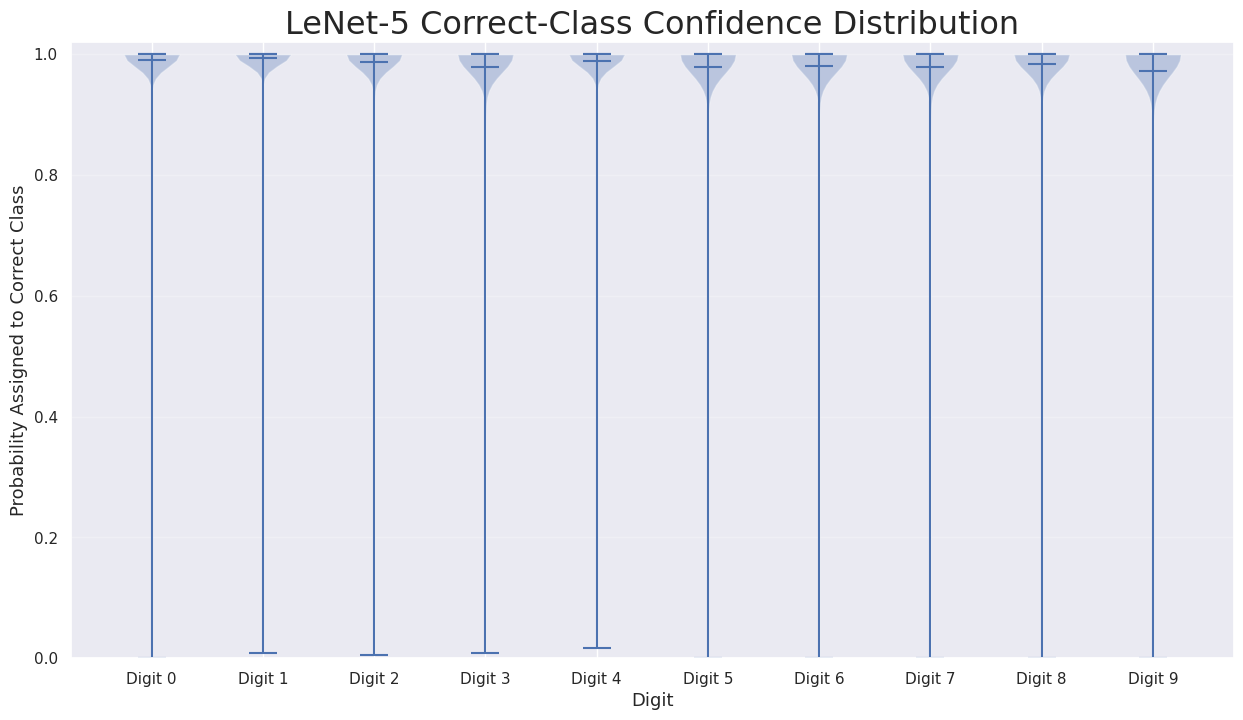

In [51]:
confidence_data = [
    probabilities[y_test == digit, digit]
    for digit in range(10)
]

plt.figure(figsize=(15, 8))

parts = plt.violinplot(
    confidence_data,
    positions=np.arange(1, 11),
    showmeans=True,
    showmedians=True,
    showextrema=True
)

plt.xticks(
    np.arange(1, 11),
    [f"Digit {i}" for i in range(10)]
)

plt.xlabel("Digit")
plt.ylabel("Probability Assigned to Correct Class")

plt.title(
    "LeNet-5 Correct-Class Confidence Distribution",
    fontsize=23
)

plt.ylim(0, 1.02)
plt.grid(axis="y", alpha=0.25)

plt.show()

In [52]:
model.save("lenet5_mnist.keras")
print("Model saved successfully.")

Model saved successfully.


In [53]:
history_df.to_csv(
    "lenet5_training_history.csv",
    index=False
)

print("Training history saved successfully.")

Training history saved successfully.


In [54]:
loaded_model = tf.keras.models.load_model("lenet5_mnist.keras")

loaded_loss, loaded_accuracy = loaded_model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print(f"Reloaded Model Accuracy: {loaded_accuracy:.5%}")

Reloaded Model Accuracy: 98.72000%


In [55]:
print("=" * 65)
print("LE⁠NET-5 MNIST PROJECT SUMMARY")
print("=" * 65)

print(f"Input Shape              : {model.input_shape}")
print(f"Total Parameters         : {model.count_params():,}")
print(f"Test Loss                : {test_loss:.5f}")
print(f"Test Accuracy            : {test_accuracy:.5%}")
print(f"Correct Predictions      : {len(correct_indices):,}")
print(f"Incorrect Predictions    : {len(incorrect_indices):,}")
print(f"Best Validation Accuracy : {history_df['val_accuracy'].max():.5%}")
print(f"Best Validation Loss     : {history_df['val_loss'].min():.5f}")

print("=" * 65)

LE⁠NET-5 MNIST PROJECT SUMMARY
Input Shape              : (None, 32, 32, 1)
Total Parameters         : 61,706
Test Loss                : 0.04529
Test Accuracy            : 98.72000%
Correct Predictions      : 9,872
Incorrect Predictions    : 128
Best Validation Accuracy : 98.95000%
Best Validation Loss     : 0.04995
